<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/emissions/CO2emsissionsinthevaluechain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ emissions across the natural-gas value chain with NeqSim

This notebook turns a gas-processing flowsheet into a transparent greenhouse-gas
inventory. NeqSim calculates the fluid state, phase separation, compressor power,
cooling duty, gas quality, and carbon carried by the product. A separate accounting
layer converts those physical results into operational and downstream CO₂.

**Audience.** Process, production, facilities, energy, and environmental engineers
who need to connect simulation results to an auditable emissions screening.

**Prerequisites.** Familiarity with mole fractions, steady-state process simulation,
compression, and basic greenhouse-gas scopes. All inputs are synthetic and public.

## Learning objectives

By the end, you can:

1. create and audit a compositional SRK natural-gas fluid;
2. connect separation, compression, cooling, pressure letdown, and recompression;
3. retrieve equipment power, heat duty, product flow, and ISO 6976 gas quality;
4. derive a fuel-specific CO₂ factor from the simulated composition;
5. distinguish operational electricity emissions from downstream product use;
6. compare gas-turbine, combined-cycle, shore-power, and wind-backed scenarios; and
7. verify balances, trends, units, scope boundaries, and limiting cases.

## Scope, equations, and reporting boundary

The steady process obeys total mass conservation:

$$
\dot{m}_{feed} =
\dot{m}_{gas} + \sum_j \dot{m}_{liquid,j}
$$

Compressor shaft power is calculated by NeqSim from the SRK enthalpy change and
specified isentropic efficiency. For the emissions layer, fuel consumed by a
generator is:

$$
\dot{m}_{fuel} =
\frac{3600 P}{\eta H_i}
$$

Here $P$ is electrical demand in kW, $\eta$ is electrical efficiency, and $H_i$
is the ISO 6976 inferior calorific value in kJ/kg. The factor 3600 converts kWh
to kJ.

Complete combustion converts each mole of carbon to one mole of CO₂:

$$
f_{CO_2} =
\frac{M_{CO_2}\sum_i x_i n_{C,i}}
{\sum_i x_i M_i}
$$

In this expression, $x_i$ is mole fraction, $n_{C,i}$ is carbon atoms per
molecule, and $M_i$ is molar mass. The result $f_{CO_2}$ is kg CO₂/kg fuel.

**Boundary.** Operational power and an illustrative CO₂-removal vent are reported
separately from potential downstream combustion of sales gas. Methane leakage,
construction, shipping, non-CO₂ gases, offsets, and avoided-emissions claims are
outside this tutorial. This is screening, not a regulatory inventory or
environmental product declaration.

## Assumptions, units, and validity limits

- Absolute pressure is in bara; temperature is in °C; flow is in kg/h or
  standard million m³/day.
- SRK is appropriate for this dry hydrocarbon gas and compression study. A
  water-rich, glycol, amine, or electrolyte system requires a suitable
  association or electrolyte model.
- NeqSim performs equilibrium and equipment calculations. Electricity factors,
  generator efficiency, CO₂-removal energy, capture rate, annual hours, and
  costs are explicit teaching assumptions.
- ISO 6976:2016 is used on a mass basis at 15 °C volume and 25 °C combustion
  reference conditions. Contractual calculations must use the specified edition
  and reference state.
- Full downstream combustion is a potential Scope 3 use-phase quantity. It is
  not an operational emission from the modeled facilities.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

The setup cell keeps Colab on public PyPI and installs only when NeqSim is absent.
It does not depend on a repository checkout, private wheel, local JAR, or runtime
restart.

In [2]:
import platform
from importlib.metadata import version

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jpype import java
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from neqsim.process import (
    compressor,
    cooler,
    newProcess,
    separator,
    stream,
    valve,
)
from neqsim.thermo import fluid


ISO6976_2016 = jpype.JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)

plt.rcParams.update(
    {
        "axes.grid": True,
        "figure.dpi": 120,
        "figure.figsize": (9, 5),
        "font.size": 10,
        "grid.alpha": 0.25,
    }
)

BLUE = "#0072B2"
ORANGE = "#E69F00"
GREEN = "#009E73"
RED = "#D55E00"
PURPLE = "#CC79A7"
SKY = "#56B4E9"

In [3]:
runtime_table = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "Python": platform.python_version(),
        "Java": str(java.lang.System.getProperty("java.version")),
    },
    name="Version",
).to_frame()
runtime_table

Out[3]: 
        Version
NeqSim   3.16.0
Python  3.12.13
Java    17.0.19


## Reproducible design basis

The synthetic feed represents a dry, moderately rich offshore gas. At 5.0
MSm³/day and 70 bara, it is separated, compressed to 140 bara, cooled, and
scrubbed for export. The receiving terminal is represented by pressure loss to
70 bara followed by transmission recompression to 100 bara.

The power-supply and removal inputs are intentionally easy to replace. Electricity
emission factors are illustrative lifecycle factors, not claims about a named
grid or asset. Costs are synthetic 2026 USD screening inputs and exclude taxes,
financing, escalation, and decommissioning.

In [4]:
feed_composition = {
    "methane": 0.850,
    "ethane": 0.070,
    "propane": 0.030,
    "i-butane": 0.010,
    "n-butane": 0.010,
    "n-pentane": 0.005,
    "n-hexane": 0.003,
    "CO2": 0.015,
    "nitrogen": 0.007,
}

design_basis = {
    "Feed standard flow [MSm³/day]": 5.0,
    "Feed pressure [bara]": 70.0,
    "Feed temperature [°C]": 35.0,
    "Offshore export pressure [bara]": 140.0,
    "Aftercooler outlet temperature [°C]": 30.0,
    "Onshore arrival pressure [bara]": 70.0,
    "Transmission pressure [bara]": 100.0,
    "Compressor isentropic efficiency [-]": 0.78,
    "Offshore auxiliary power [MW]": 1.20,
    "Onshore auxiliary power [MW]": 1.80,
    "Cooler electrical fraction [-]": 0.015,
    "CO2 removal fraction [-]": 0.60,
    "CO2 capture fraction [-]": 0.95,
    "Removal electricity [kWh/kg CO2 removed]": 0.22,
    "Annual operating hours [h/year]": 8_000.0,
    "Energy per boe [GJ/boe]": 6.12,
}

supply_assumptions = pd.DataFrame(
    {
        "Electrical efficiency [-]": [
            0.36,
            0.52,
            np.nan,
            np.nan,
        ],
        "Electricity factor [kg CO2e/kWh]": [
            np.nan,
            np.nan,
            0.018,
            0.012,
        ],
        "Gas-backed fraction [-]": [
            1.00,
            1.00,
            0.00,
            0.15,
        ],
    },
    index=[
        "Simple-cycle gas turbine",
        "Combined cycle",
        "Power from shore",
        "Wind-backed hybrid",
    ],
)

composition_table = pd.Series(
    feed_composition,
    name="Feed mole fraction [-]",
).to_frame()
composition_table.loc["Total"] = composition_table.sum()
composition_table

Out[4]: 
           Feed mole fraction [-]
methane                     0.850
ethane                      0.070
propane                     0.030
i-butane                    0.010
n-butane                    0.010
n-pentane                   0.005
n-hexane                    0.003
CO2                         0.015
nitrogen                    0.007
Total                       1.000


NeqSim normalizes component amounts, but the explicit sum check prevents a hidden
composition error. The heavier components influence molecular weight, calorific
value, phase behavior, and compressor duty even at small mole fractions.

In [5]:
carbon_atoms = {
    "methane": 1,
    "ethane": 2,
    "propane": 3,
    "i-butane": 4,
    "n-butane": 4,
    "n-pentane": 5,
    "n-hexane": 6,
    "CO2": 1,
    "nitrogen": 0,
}


def build_feed_fluid(
    co2_mole_fraction=feed_composition["CO2"],
):
    methane_adjustment = (
        feed_composition["CO2"] - co2_mole_fraction
    )
    case_composition = feed_composition.copy()
    case_composition["CO2"] = co2_mole_fraction
    case_composition["methane"] += methane_adjustment

    case_fluid = fluid("srk")
    for component_name, mole_fraction in case_composition.items():
        case_fluid.addComponent(
            component_name,
            mole_fraction,
        )

    case_fluid.setMixingRule("classic")
    case_fluid.setTemperature(
        design_basis["Feed temperature [°C]"],
        "C",
    )
    case_fluid.setPressure(
        design_basis["Feed pressure [bara]"],
        "bara",
    )
    case_fluid.init(0)
    return case_fluid


base_fluid = build_feed_fluid()
normalized_sum = sum(
    base_fluid.getComponent(index).getz()
    for index in range(base_fluid.getNumberOfComponents())
)
print(f"Normalized mole-fraction sum: {normalized_sum:.12f} [-]")

Normalized mole-fraction sum: 1.000000000000 [-]


## How NeqSim represents and solves this problem

A NeqSim thermodynamic system stores component amounts, temperature, pressure,
equation of state, and mixing rule. A `Stream` carries a cloned thermodynamic
state and flow rate. `Separator`, `Compressor`, `Cooler`, and `Valve` objects
consume upstream streams and expose calculated outlet streams.

A `ProcessSystem` owns the connected objects and calls them in dependency order.
The separator performs an equilibrium flash, the compressor solves an
enthalpy-based pressure rise, the cooler solves a specified outlet-temperature
duty, and the valve performs isenthalpic pressure reduction. Results are read
from those same solved objects—there is no second, disconnected spreadsheet
flowsheet.

# CO₂ emissions from subsea and offshore processing

This preserved section now calculates offshore process power, including export
compression and cooler auxiliaries. A production-water injection pump or gas
reinjection compressor can be added to the returned process in the same pattern;
they are outside this dry-gas design basis.

## Figure 1 — model and accounting workflow

Solid blocks are NeqSim unit operations. The accounting blocks consume calculated
duties, flows, gas quality, and composition. This separation keeps thermodynamics
reproducible while making scenario assumptions visible.

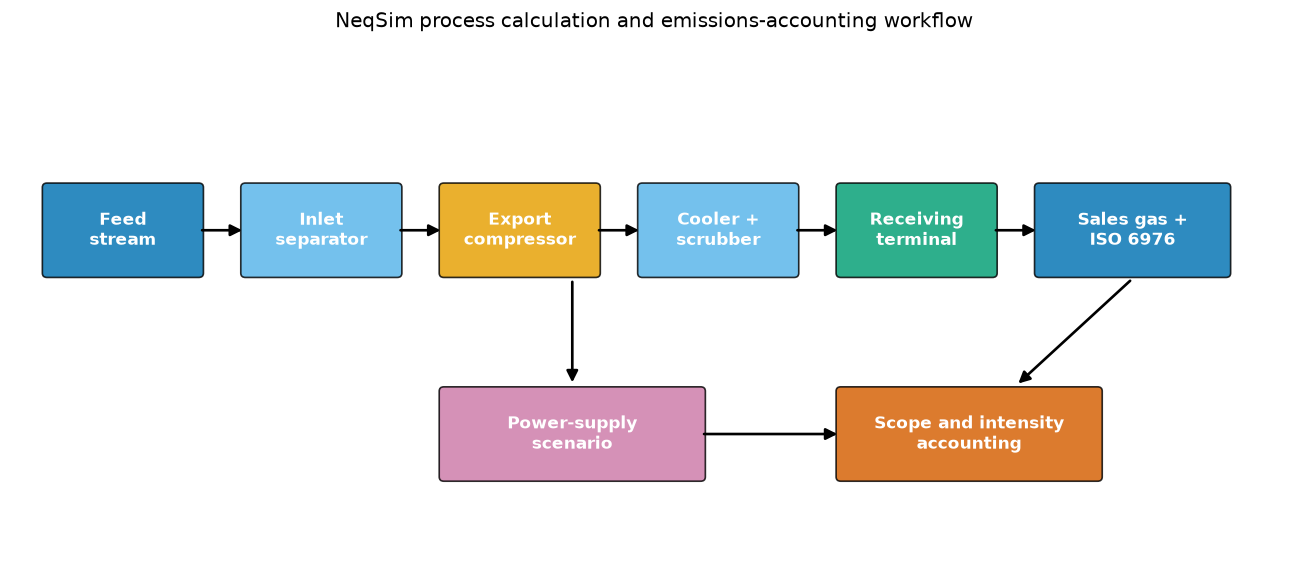

In [6]:
figure, axis = plt.subplots(figsize=(11, 4.8))
axis.set_xlim(0, 11)
axis.set_ylim(0, 4.8)
axis.axis("off")

blocks = [
    (0.3, 2.6, 1.3, 0.8, "Feed\nstream", BLUE),
    (2.0, 2.6, 1.3, 0.8, "Inlet\nseparator", SKY),
    (3.7, 2.6, 1.3, 0.8, "Export\ncompressor", ORANGE),
    (5.4, 2.6, 1.3, 0.8, "Cooler +\nscrubber", SKY),
    (7.1, 2.6, 1.3, 0.8, "Receiving\nterminal", GREEN),
    (8.8, 2.6, 1.6, 0.8, "Sales gas +\nISO 6976", BLUE),
    (3.7, 0.7, 2.2, 0.8, "Power-supply\nscenario", PURPLE),
    (7.1, 0.7, 2.2, 0.8, "Scope and intensity\naccounting", RED),
]

for x_position, y_position, width, height, label, color in blocks:
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.04",
        facecolor=color,
        edgecolor="black",
        alpha=0.82,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

for x_start, x_end in [
    (1.6, 2.0),
    (3.3, 3.7),
    (5.0, 5.4),
    (6.7, 7.1),
    (8.4, 8.8),
]:
    axis.add_patch(
        FancyArrowPatch(
            (x_start, 3.0),
            (x_end, 3.0),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.6,
            color="black",
        )
    )

axis.add_patch(
    FancyArrowPatch(
        (4.8, 2.55),
        (4.8, 1.55),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.6,
        color="black",
    )
)
axis.add_patch(
    FancyArrowPatch(
        (5.9, 1.1),
        (7.1, 1.1),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.6,
        color="black",
    )
)
axis.add_patch(
    FancyArrowPatch(
        (9.6, 2.55),
        (8.6, 1.55),
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.6,
        color="black",
    )
)

axis.set_title(
    "NeqSim process calculation and emissions-accounting workflow"
)
figure.tight_layout()
plt.show()

The diagram shows the practical reuse pattern: change a physical input, rerun the
process, retrieve calculated loads and product properties, then reevaluate the
inventory. Scenario factors never alter the thermodynamic solution.

In [7]:
def run_offshore_process(
    export_pressure_bara,
    feed_rate_msm3_day=design_basis[
        "Feed standard flow [MSm³/day]"
    ],
    co2_mole_fraction=feed_composition["CO2"],
):
    process = newProcess(
        f"Offshore gas export at {export_pressure_bara:.0f} bara"
    )
    case_fluid = build_feed_fluid(co2_mole_fraction)

    feed = stream(
        "well gas feed",
        case_fluid,
        process=process,
    )
    feed.setFlowRate(
        feed_rate_msm3_day,
        "MSm3/day",
    )
    feed.setTemperature(
        design_basis["Feed temperature [°C]"],
        "C",
    )
    feed.setPressure(
        design_basis["Feed pressure [bara]"],
        "bara",
    )

    inlet_separator = separator(
        "inlet separator",
        feed,
        process=process,
    )
    export_compressor = compressor(
        "offshore export compressor",
        inlet_separator.getGasOutStream(),
        pres=export_pressure_bara,
        process=process,
    )
    export_compressor.setIsentropicEfficiency(
        design_basis["Compressor isentropic efficiency [-]"]
    )

    export_aftercooler = cooler(
        "export aftercooler",
        export_compressor.getOutStream(),
        process=process,
    )
    export_aftercooler.setOutTemperature(
        design_basis["Aftercooler outlet temperature [°C]"],
        "C",
    )
    export_scrubber = separator(
        "export scrubber",
        export_aftercooler.getOutStream(),
        process=process,
    )

    process.run()
    return {
        "process": process,
        "feed": feed,
        "inlet separator": inlet_separator,
        "compressor": export_compressor,
        "aftercooler": export_aftercooler,
        "scrubber": export_scrubber,
        "export gas": export_scrubber.getGasOutStream(),
        "inlet liquid": inlet_separator.getLiquidOutStream(),
        "scrubber liquid": export_scrubber.getLiquidOutStream(),
    }


offshore_case = run_offshore_process(
    design_basis["Offshore export pressure [bara]"]
)

The helper returns every important object, making intermediate checks and reuse
straightforward. Each sensitivity case constructs a new `ProcessSystem`, so
results cannot depend on stale state from a previous calculation.

In [8]:
def stream_row(stream_object, label):
    return {
        "Stream": label,
        "Flow [kg/h]": stream_object.getFlowRate("kg/hr"),
        "Temperature [°C]": stream_object.getTemperature("C"),
        "Pressure [bara]": stream_object.getPressure("bara"),
        "Phases [-]": int(
            stream_object.getFluid().getNumberOfPhases()
        ),
    }


offshore_streams = pd.DataFrame(
    [
        stream_row(offshore_case["feed"], "Feed"),
        stream_row(
            offshore_case["compressor"].getOutStream(),
            "Compressor discharge",
        ),
        stream_row(
            offshore_case["aftercooler"].getOutStream(),
            "Aftercooler outlet",
        ),
        stream_row(offshore_case["export gas"], "Export gas"),
        stream_row(
            offshore_case["inlet liquid"],
            "Inlet liquid",
        ),
        stream_row(
            offshore_case["scrubber liquid"],
            "Scrubber liquid",
        ),
    ]
).set_index("Stream")
offshore_streams.round(4)

Out[8]: 
                      Flow [kg/h]  ...  Phases [-]
Stream                             ...            
Feed                  173596.3237  ...           1
Compressor discharge  173596.3237  ...           1
Aftercooler outlet    173596.3237  ...           1
Export gas            173596.3237  ...           1
Inlet liquid               0.0000  ...           2
Scrubber liquid            0.0000  ...           2

[6 rows x 4 columns]


The feed and three final products provide an independent mass closure. The
normalized residual is:

$$
\epsilon_m =
\frac{\dot{m}_{feed} - \dot{m}_{gas}
- \dot{m}_{inlet\ liquid} - \dot{m}_{scrubber\ liquid}}
{\dot{m}_{feed}}
$$

A residual near machine precision verifies connectivity; it does not prove that
the chosen fluid model or operating basis matches a real asset.

In [9]:
feed_mass_kg_h = offshore_case["feed"].getFlowRate("kg/hr")
export_mass_kg_h = offshore_case["export gas"].getFlowRate("kg/hr")
inlet_liquid_kg_h = offshore_case["inlet liquid"].getFlowRate(
    "kg/hr"
)
scrubber_liquid_kg_h = offshore_case[
    "scrubber liquid"
].getFlowRate("kg/hr")

offshore_mass_residual_kg_h = (
    feed_mass_kg_h
    - export_mass_kg_h
    - inlet_liquid_kg_h
    - scrubber_liquid_kg_h
)
normalized_mass_residual = (
    offshore_mass_residual_kg_h / feed_mass_kg_h
)

pd.Series(
    {
        "Feed [kg/h]": feed_mass_kg_h,
        "Export gas [kg/h]": export_mass_kg_h,
        "Inlet liquid [kg/h]": inlet_liquid_kg_h,
        "Scrubber liquid [kg/h]": scrubber_liquid_kg_h,
        "Mass residual [kg/h]": offshore_mass_residual_kg_h,
        "Normalized residual [-]": normalized_mass_residual,
    },
    name="Offshore balance",
).to_frame().round(8)

Out[9]: 
                         Offshore balance
Feed [kg/h]                 173596.323679
Export gas [kg/h]           173596.323679
Inlet liquid [kg/h]              0.000000
Scrubber liquid [kg/h]           0.000000
Mass residual [kg/h]            -0.000000
Normalized residual [-]         -0.000000


The separator liquid rows remain explicit even when the dry-gas case produces
very little liquid. This avoids silently assuming that all inlet mass becomes
sales gas.

In [10]:
compressor_power_mw = offshore_case["compressor"].getPower("MW")
cooler_duty_mw = abs(
    offshore_case["aftercooler"].getDuty()
) / 1.0e6
cooler_electricity_mw = (
    cooler_duty_mw
    * design_basis["Cooler electrical fraction [-]"]
)
offshore_auxiliary_mw = design_basis[
    "Offshore auxiliary power [MW]"
]
offshore_total_power_mw = (
    compressor_power_mw
    + cooler_electricity_mw
    + offshore_auxiliary_mw
)

offshore_power = pd.Series(
    {
        "Export compressor": compressor_power_mw,
        "Cooler auxiliaries": cooler_electricity_mw,
        "Other offshore auxiliaries": offshore_auxiliary_mw,
    },
    name="Electrical demand [MW]",
)
offshore_power.to_frame().round(4)

Out[10]: 
                            Electrical demand [MW]
Export compressor                           5.2598
Cooler auxiliaries                          0.1462
Other offshore auxiliaries                  1.2000


## Figure 2 — offshore power and thermal duty

Shaft power is a NeqSim result. Cooler electricity is an explicit 1.5% fraction
of calculated heat rejection, while other auxiliaries are an explicit design
allowance. The second panel keeps thermal and electrical quantities distinct.

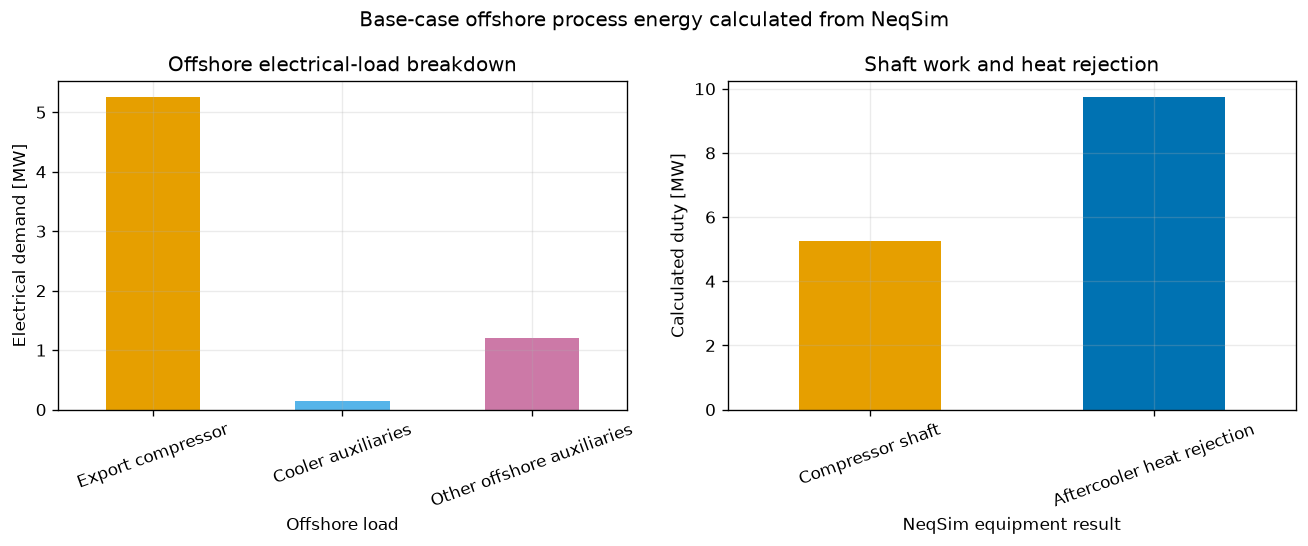

In [11]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.6),
)

offshore_power.plot.bar(
    ax=axes[0],
    color=[ORANGE, SKY, PURPLE],
)
axes[0].set_ylabel("Electrical demand [MW]")
axes[0].set_xlabel("Offshore load")
axes[0].set_title("Offshore electrical-load breakdown")
axes[0].tick_params(axis="x", rotation=20)

duty_values = pd.Series(
    {
        "Compressor shaft": compressor_power_mw,
        "Aftercooler heat rejection": cooler_duty_mw,
    }
)
duty_values.plot.bar(
    ax=axes[1],
    color=[ORANGE, BLUE],
)
axes[1].set_ylabel("Calculated duty [MW]")
axes[1].set_xlabel("NeqSim equipment result")
axes[1].set_title("Shaft work and heat rejection")
axes[1].tick_params(axis="x", rotation=20)

figure.suptitle(
    "Base-case offshore process energy calculated from NeqSim"
)
figure.tight_layout()
plt.show()

Compression dominates controllable offshore electrical demand. Heat rejection is
not electricity; the fan/pump allowance converts only a small, stated fraction
into electrical load.

In [12]:
def iso6976_mass_properties(process_stream):
    standard = ISO6976_2016(
        process_stream.getFluid(),
        15.0,
        25.0,
        "mass",
    )
    standard.setReferenceState("real")
    standard.calculate()
    return {
        "LCV [kJ/kg]": float(standard.getValue("LCV")),
        "GCV [kJ/kg]": float(standard.getValue("GCV")),
        "Molar mass [g/mol]": float(
            standard.getValue("MolarMass")
        ),
        "Relative density [-]": float(
            standard.getValue("RelativeDensity")
        ),
    }


gas_quality = pd.Series(
    iso6976_mass_properties(offshore_case["export gas"]),
    name="ISO 6976:2016 result",
)
gas_quality.to_frame().round(4)

Out[12]: 
                      ISO 6976:2016 result
LCV [kJ/kg]                     46928.9131
GCV [kJ/kg]                     51799.2807
Molar mass [g/mol]                 19.7017
Relative density [-]                0.6820


ISO 6976 provides the inferior calorific value used to convert process power into
fuel rate. Calculating it from the actual export composition is more traceable
than assuming a generic natural-gas heating value.

## Power generation alternatives

The preserved alternatives—gas turbine, combined cycle, wind, and power from
shore—are now evaluated on a common electrical-demand basis. Fuel-fired options
use the NeqSim/ISO gas quality and a composition-derived carbon factor. Imported
and wind-backed power use explicit illustrative electricity factors.

In [13]:
def composition_carbon_factor(process_stream):
    stream_fluid = process_stream.getFluid()
    mixture_molar_mass_kg_mol = float(
        stream_fluid.getMolarMass()
    )
    carbon_moles_per_mole = 0.0

    for component_name, atoms in carbon_atoms.items():
        mole_fraction = float(
            stream_fluid.getComponent(component_name).getz()
        )
        carbon_moles_per_mole += mole_fraction * atoms

    co2_molar_mass_kg_mol = 0.0440095
    return (
        carbon_moles_per_mole
        * co2_molar_mass_kg_mol
        / mixture_molar_mass_kg_mol
    )


fuel_carbon_factor_kg_kg = composition_carbon_factor(
    offshore_case["export gas"]
)
fuel_lcv_kj_kg = gas_quality["LCV [kJ/kg]"]

fuel_characteristics = pd.Series(
    {
        "Fuel LCV [MJ/kg]": fuel_lcv_kj_kg / 1_000.0,
        "Complete-combustion factor [kg CO2/kg fuel]": (
            fuel_carbon_factor_kg_kg
        ),
    },
    name="Composition-derived value",
)
fuel_characteristics.to_frame().round(5)

Out[13]: 
                                             Composition-derived value
Fuel LCV [MJ/kg]                                              46.92891
Complete-combustion factor [kg CO2/kg fuel]                    2.72067


The carbon factor includes both hydrocarbon carbon and inlet CO₂ that would leave
with combustion products. It assumes complete combustion and excludes methane
slip, nitrous oxide, and upstream fuel-supply emissions.

In [14]:
def fuel_power_factor_kg_kwh(electrical_efficiency):
    fuel_required_kg_kwh = (
        3_600.0
        / electrical_efficiency
        / fuel_lcv_kj_kg
    )
    return (
        fuel_required_kg_kwh
        * fuel_carbon_factor_kg_kg
    )


simple_cycle_factor = fuel_power_factor_kg_kwh(
    supply_assumptions.loc[
        "Simple-cycle gas turbine",
        "Electrical efficiency [-]",
    ]
)
combined_cycle_factor = fuel_power_factor_kg_kwh(
    supply_assumptions.loc[
        "Combined cycle",
        "Electrical efficiency [-]",
    ]
)

wind_factor = supply_assumptions.loc[
    "Wind-backed hybrid",
    "Electricity factor [kg CO2e/kWh]",
]
wind_gas_fraction = supply_assumptions.loc[
    "Wind-backed hybrid",
    "Gas-backed fraction [-]",
]
wind_hybrid_factor = (
    (1.0 - wind_gas_fraction) * wind_factor
    + wind_gas_fraction * simple_cycle_factor
)

power_supply_factors = pd.Series(
    {
        "Simple-cycle gas turbine": simple_cycle_factor,
        "Combined cycle": combined_cycle_factor,
        "Power from shore": supply_assumptions.loc[
            "Power from shore",
            "Electricity factor [kg CO2e/kWh]",
        ],
        "Wind-backed hybrid": wind_hybrid_factor,
    },
    name="Effective factor [kg CO2e/kWh]",
)
power_supply_factors.to_frame().round(5)

Out[14]: 
                          Effective factor [kg CO2e/kWh]
Simple-cycle gas turbine                         0.57974
Combined cycle                                   0.40136
Power from shore                                 0.01800
Wind-backed hybrid                               0.09716


In [15]:
def power_emissions_kg_h(
    electrical_power_mw,
    supply_factor_kg_kwh,
):
    return (
        electrical_power_mw
        * 1_000.0
        * supply_factor_kg_kwh
    )


offshore_power_emissions = (
    power_supply_factors
    * offshore_total_power_mw
    * 1_000.0
)
offshore_power_emissions.name = "Offshore power CO2e [kg/h]"
offshore_power_emissions.to_frame().round(2)

Out[15]: 
                          Offshore power CO2e [kg/h]
Simple-cycle gas turbine                     3829.79
Combined cycle                               2651.39
Power from shore                              118.91
Wind-backed hybrid                            641.85


# CO₂ emissions from onshore processing

The receiving-terminal model preserves the original onshore power calculation
while making it executable. A valve represents transmission/arrival pressure
loss, a separator protects the compressor, and NeqSim calculates recompression
and cooling. CO₂-removal electricity is added transparently because this notebook
does not model a detailed amine or membrane unit.

In [16]:
def run_onshore_process(export_stream):
    process = newProcess("Onshore receiving and transmission")
    receiving_fluid = export_stream.getFluid().clone()

    arrival_feed = stream(
        "onshore arrival gas",
        receiving_fluid,
        process=process,
    )
    arrival_feed.setFlowRate(
        export_stream.getFlowRate("kg/hr"),
        "kg/hr",
    )
    arrival_feed.setTemperature(
        export_stream.getTemperature("C"),
        "C",
    )
    arrival_feed.setPressure(
        export_stream.getPressure("bara"),
        "bara",
    )

    arrival_valve = valve(
        "arrival pressure loss",
        arrival_feed,
        process=process,
    )
    arrival_valve.setOutletPressure(
        design_basis["Onshore arrival pressure [bara]"],
        "bara",
    )
    receiving_separator = separator(
        "receiving separator",
        arrival_valve.getOutStream(),
        process=process,
    )
    transmission_compressor = compressor(
        "transmission compressor",
        receiving_separator.getGasOutStream(),
        pres=design_basis["Transmission pressure [bara]"],
        process=process,
    )
    transmission_compressor.setIsentropicEfficiency(
        design_basis["Compressor isentropic efficiency [-]"]
    )
    transmission_cooler = cooler(
        "transmission cooler",
        transmission_compressor.getOutStream(),
        process=process,
    )
    transmission_cooler.setOutTemperature(
        design_basis["Aftercooler outlet temperature [°C]"],
        "C",
    )

    process.run()
    return {
        "process": process,
        "feed": arrival_feed,
        "valve": arrival_valve,
        "separator": receiving_separator,
        "compressor": transmission_compressor,
        "cooler": transmission_cooler,
        "sales gas": transmission_cooler.getOutStream(),
        "liquid": receiving_separator.getLiquidOutStream(),
    }


onshore_case = run_onshore_process(offshore_case["export gas"])

The arrival valve is a boundary simplification, not a pipeline model. Replace it
with a NeqSim pipeline unit when length, diameter, heat transfer, elevation, and
hydraulic capacity are part of the question.

In [17]:
def component_mass_flow_kg_h(
    process_stream,
    component_name,
):
    stream_fluid = process_stream.getFluid()
    component = stream_fluid.getComponent(component_name)
    return (
        process_stream.getFlowRate("mole/sec")
        * component.getz()
        * component.getMolarMass()
        * 3_600.0
    )


raw_co2_kg_h = component_mass_flow_kg_h(
    offshore_case["export gas"],
    "CO2",
)
removed_co2_kg_h = (
    raw_co2_kg_h
    * design_basis["CO2 removal fraction [-]"]
)
stored_co2_kg_h = (
    removed_co2_kg_h
    * design_basis["CO2 capture fraction [-]"]
)
removal_vent_co2_kg_h = removed_co2_kg_h - stored_co2_kg_h

onshore_compressor_power_mw = onshore_case[
    "compressor"
].getPower("MW")
onshore_cooler_duty_mw = abs(
    onshore_case["cooler"].getDuty()
) / 1.0e6
onshore_cooler_electricity_mw = (
    onshore_cooler_duty_mw
    * design_basis["Cooler electrical fraction [-]"]
)
removal_electricity_mw = (
    removed_co2_kg_h
    * design_basis[
        "Removal electricity [kWh/kg CO2 removed]"
    ]
    / 1_000.0
)
onshore_auxiliary_mw = design_basis[
    "Onshore auxiliary power [MW]"
]
onshore_total_power_mw = (
    onshore_compressor_power_mw
    + onshore_cooler_electricity_mw
    + removal_electricity_mw
    + onshore_auxiliary_mw
)

onshore_power = pd.Series(
    {
        "Transmission compressor": onshore_compressor_power_mw,
        "Cooler auxiliaries": onshore_cooler_electricity_mw,
        "CO2 removal": removal_electricity_mw,
        "Other onshore auxiliaries": onshore_auxiliary_mw,
    },
    name="Electrical demand [MW]",
)
onshore_power.to_frame().round(4)

Out[17]: 
                           Electrical demand [MW]
Transmission compressor                    2.0819
Cooler auxiliaries                         0.0039
CO2 removal                                0.7678
Other onshore auxiliaries                  1.8000


The removal calculation separates three quantities: CO₂ removed from sales gas,
CO₂ sent to storage, and uncaptured CO₂ vented. A real design must replace the
simple fractions with a validated solvent, membrane, adsorption, or cryogenic
model and include regeneration heat, solvent circulation, compression, and
transport.

# Total emissions calculations

Operational scenarios combine offshore and onshore electrical demand with the
same supply factors. The removal vent is added as a direct release. Captured CO₂
is reported separately and is not counted as a negative emission.

In [18]:
total_process_power_mw = (
    offshore_total_power_mw + onshore_total_power_mw
)
operational_emissions = pd.DataFrame(
    {
        "Power emissions [kg CO2e/h]": (
            power_supply_factors
            * total_process_power_mw
            * 1_000.0
        ),
        "CO2-removal vent [kg CO2/h]": removal_vent_co2_kg_h,
    }
)
operational_emissions[
    "Operational total [kg CO2e/h]"
] = operational_emissions.sum(axis=1)

operational_summary = pd.concat(
    [
        pd.Series(
            {
                "Offshore power [MW]": offshore_total_power_mw,
                "Onshore power [MW]": onshore_total_power_mw,
                "Total process power [MW]": total_process_power_mw,
                "CO2 removed [kg/h]": removed_co2_kg_h,
                "CO2 sent to storage [kg/h]": stored_co2_kg_h,
                "CO2 removal vent [kg/h]": removal_vent_co2_kg_h,
            },
            name="Base-case result",
        ),
        operational_emissions[
            ["Operational total [kg CO2e/h]"]
        ].T,
    ]
)
operational_emissions.round(2)

Out[18]: 
                          Power emissions [kg CO2e/h]  ...  Operational total [kg CO2e/h]
Simple-cycle gas turbine                      6527.64  ...                        6702.13
Combined cycle                                4519.13  ...                        4693.63
Power from shore                               202.67  ...                         377.17
Wind-backed hybrid                            1093.99  ...                        1268.49

[4 rows x 3 columns]


## Figure 3 — operational supply scenarios

All columns serve the same calculated demand. The comparison therefore isolates
the power-supply assumption rather than mixing different production rates or
process configurations.

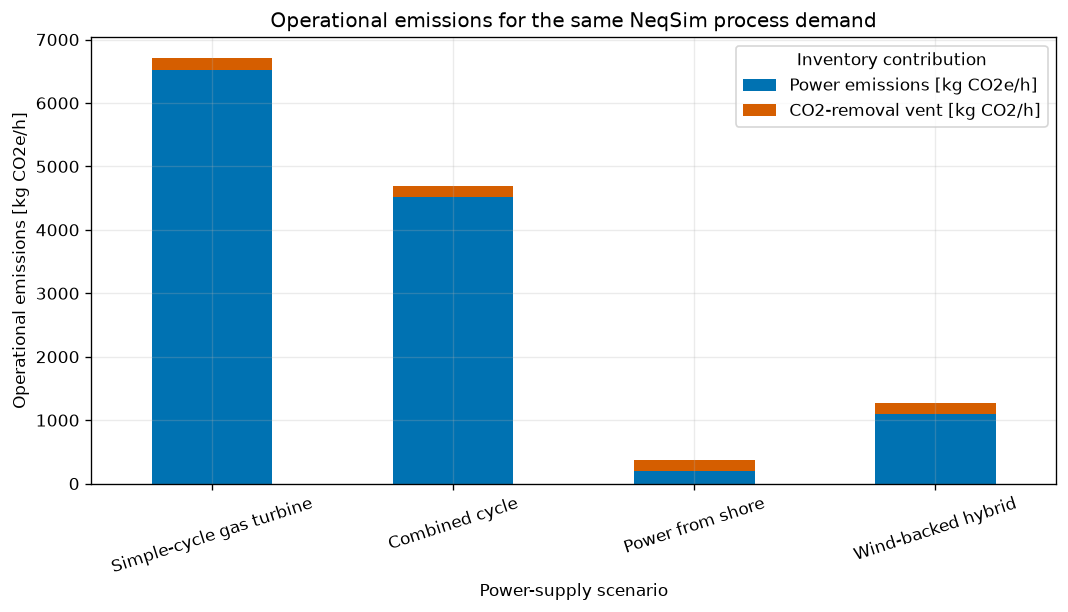

In [19]:
figure, axis = plt.subplots(figsize=(9, 5.2))
operational_emissions[
    [
        "Power emissions [kg CO2e/h]",
        "CO2-removal vent [kg CO2/h]",
    ]
].plot.bar(
    stacked=True,
    ax=axis,
    color=[BLUE, RED],
)
axis.set_ylabel("Operational emissions [kg CO2e/h]")
axis.set_xlabel("Power-supply scenario")
axis.set_title(
    "Operational emissions for the same NeqSim process demand"
)
axis.legend(
    title="Inventory contribution",
    loc="upper right",
)
axis.tick_params(axis="x", rotation=18)
figure.tight_layout()
plt.show()

Lower-carbon electricity reduces power-related emissions, but the direct
uncaptured CO₂ remains. This floor makes capture efficiency and vent treatment
visible rather than hiding them inside an aggregate factor.

## Emissions from use of oil and gas

This preserved section estimates potential CO₂ if all sales gas is eventually
combusted. The estimate uses NeqSim product molar flow and composition, not a
fixed kg/boe factor. Separated condensate is outside this gas-only use-phase
boundary and should be added in a full product inventory.

In [20]:
def complete_combustion_co2_kg_h(process_stream):
    stream_fluid = process_stream.getFluid()
    total_molar_rate_mol_s = process_stream.getFlowRate(
        "mole/sec"
    )
    carbon_rate_mol_s = 0.0

    for component_name, atoms in carbon_atoms.items():
        mole_fraction = float(
            stream_fluid.getComponent(component_name).getz()
        )
        carbon_rate_mol_s += (
            total_molar_rate_mol_s
            * mole_fraction
            * atoms
        )

    return carbon_rate_mol_s * 0.0440095 * 3_600.0


raw_product_combustion_co2_kg_h = (
    complete_combustion_co2_kg_h(
        offshore_case["export gas"]
    )
)
sales_gas_combustion_co2_kg_h = (
    raw_product_combustion_co2_kg_h
    - removed_co2_kg_h
)
export_energy_gj_h = (
    offshore_case["export gas"].getFlowRate("kg/hr")
    * fuel_lcv_kj_kg
    / 1.0e6
)
export_energy_boe_h = (
    export_energy_gj_h
    / design_basis["Energy per boe [GJ/boe]"]
)

use_phase = pd.Series(
    {
        "Raw gas complete-combustion CO2 [kg/h]": (
            raw_product_combustion_co2_kg_h
        ),
        "Removed feed CO2 [kg/h]": removed_co2_kg_h,
        "Sales-gas use-phase CO2 [kg/h]": (
            sales_gas_combustion_co2_kg_h
        ),
        "Sales-gas energy [GJ/h]": export_energy_gj_h,
        "Sales-gas energy equivalent [boe/h]": (
            export_energy_boe_h
        ),
    },
    name="Potential downstream result",
)
use_phase.to_frame().round(3)

Out[20]: 
                                        Potential downstream result
Raw gas complete-combustion CO2 [kg/h]                   472298.228
Removed feed CO2 [kg/h]                                    3489.928
Sales-gas use-phase CO2 [kg/h]                           468808.300
Sales-gas energy [GJ/h]                                    8146.687
Sales-gas energy equivalent [boe/h]                        1331.158


CO₂ already present in the feed is subtracted when it is removed before sale.
Hydrocarbon carbon remains in the product and becomes downstream CO₂ under the
complete-combustion assumption. Storage and downstream use must not be double
counted.

## Total emissions calculations

The scope view below follows a teaching convention:

- Scope 1: fuel-fired power plus the removal vent;
- Scope 2: imported or wind-backed electricity plus the removal vent;
- Scope 3 use: potential complete combustion of sales gas.

Exact category treatment depends on organizational control, contracts, and the
reporting standard. The labels are a boundary aid, not an assurance opinion.

In [21]:
baseline_operational_kg_h = operational_emissions.loc[
    "Simple-cycle gas turbine",
    "Operational total [kg CO2e/h]",
]
shore_operational_kg_h = operational_emissions.loc[
    "Power from shore",
    "Operational total [kg CO2e/h]",
]
baseline_total_kg_h = (
    baseline_operational_kg_h
    + sales_gas_combustion_co2_kg_h
)
shore_total_kg_h = (
    shore_operational_kg_h
    + sales_gas_combustion_co2_kg_h
)

emissions_intensity = pd.DataFrame(
    {
        "Operational [kg CO2e/boe]": (
            operational_emissions[
                "Operational total [kg CO2e/h]"
            ]
            / export_energy_boe_h
        ),
        "Use phase [kg CO2/boe]": (
            sales_gas_combustion_co2_kg_h
            / export_energy_boe_h
        ),
    }
)
emissions_intensity[
    "Combined [kg CO2e/boe]"
] = emissions_intensity.sum(axis=1)
emissions_intensity.round(3)

Out[21]: 
                          Operational [kg CO2e/boe]  ...  Combined [kg CO2e/boe]
Simple-cycle gas turbine                      5.035  ...                 357.216
Combined cycle                                3.526  ...                 355.707
Power from shore                              0.283  ...                 352.464
Wind-backed hybrid                            0.953  ...                 353.134

[4 rows x 3 columns]


## Figure 4 — operational versus downstream scale

A logarithmic axis keeps both contributions readable. The downstream bar is
potential product use, not an operational facility release. The visual prevents
the common error of presenting electrification as eliminating product carbon.

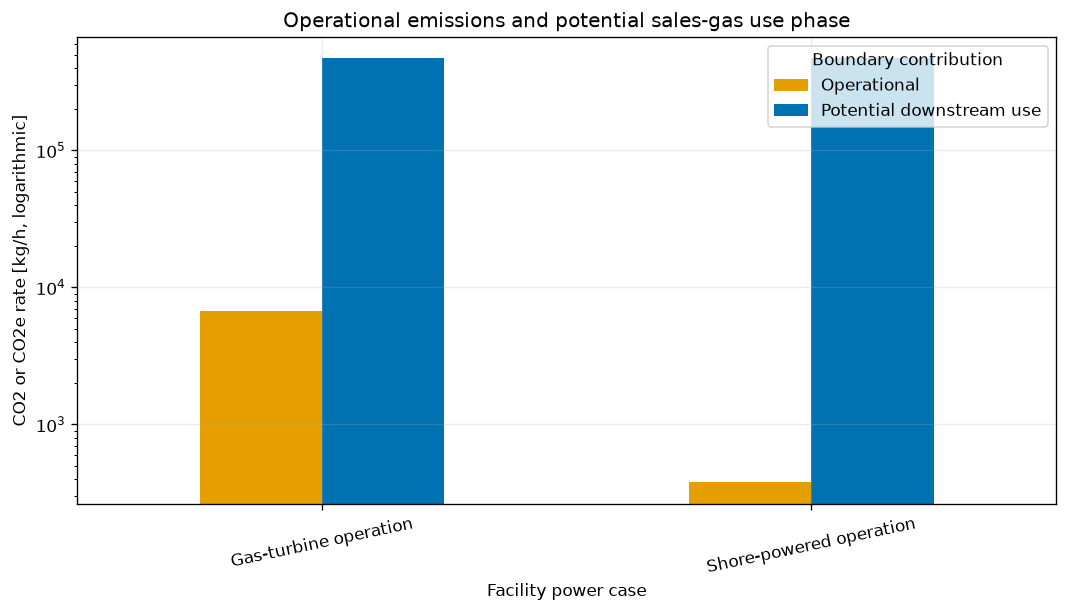

In [22]:
scope_comparison = pd.DataFrame(
    {
        "Operational": [
            baseline_operational_kg_h,
            shore_operational_kg_h,
        ],
        "Potential downstream use": [
            sales_gas_combustion_co2_kg_h,
            sales_gas_combustion_co2_kg_h,
        ],
    },
    index=[
        "Gas-turbine operation",
        "Shore-powered operation",
    ],
)

figure, axis = plt.subplots(figsize=(9, 5.2))
scope_comparison.plot.bar(
    ax=axis,
    color=[ORANGE, BLUE],
)
axis.set_yscale("log")
axis.set_ylabel("CO2 or CO2e rate [kg/h, logarithmic]")
axis.set_xlabel("Facility power case")
axis.set_title(
    "Operational emissions and potential sales-gas use phase"
)
axis.legend(
    title="Boundary contribution",
    loc="upper right",
)
axis.tick_params(axis="x", rotation=12)
figure.tight_layout()
plt.show()

Electrification materially changes the operational bar while the product-use bar
is unchanged. Decarbonizing gas use therefore requires a different intervention
from decarbonizing facility power.

## Sensitivity: export pressure and electrification

The final application reruns NeqSim at five export pressures. For each solved
compressor duty, it blends simple-cycle and shore-power factors over six
electrification fractions. This is the reusable workflow: build independent
cases, solve, retrieve, account, and compare.

In [23]:
export_pressures_bara = np.array(
    [100.0, 115.0, 130.0, 145.0, 160.0]
)
electrification_fractions = np.linspace(
    0.0,
    1.0,
    6,
)
pressure_results = []

for export_pressure_bara in export_pressures_bara:
    pressure_case = run_offshore_process(
        export_pressure_bara
    )
    pressure_compressor_mw = pressure_case[
        "compressor"
    ].getPower("MW")
    pressure_cooler_mw = (
        abs(pressure_case["aftercooler"].getDuty())
        / 1.0e6
        * design_basis["Cooler electrical fraction [-]"]
    )
    pressure_offshore_total_mw = (
        pressure_compressor_mw
        + pressure_cooler_mw
        + design_basis["Offshore auxiliary power [MW]"]
    )
    pressure_results.append(
        {
            "Export pressure [bara]": export_pressure_bara,
            "Offshore compressor [MW]": pressure_compressor_mw,
            "Offshore total [MW]": pressure_offshore_total_mw,
            "Normalized mass residual [-]": (
                pressure_case["feed"].getFlowRate("kg/hr")
                - pressure_case["export gas"].getFlowRate("kg/hr")
                - pressure_case["inlet liquid"].getFlowRate(
                    "kg/hr"
                )
                - pressure_case["scrubber liquid"].getFlowRate(
                    "kg/hr"
                )
            )
            / pressure_case["feed"].getFlowRate("kg/hr"),
        }
    )

pressure_table = pd.DataFrame(pressure_results).set_index(
    "Export pressure [bara]"
)
pressure_table.round(5)

Out[23]: 
                        Offshore compressor [MW]  ...  Normalized mass residual [-]
Export pressure [bara]                            ...                              
100.0                                    2.56867  ...                          -0.0
115.0                                    3.65144  ...                          -0.0
130.0                                    4.64158  ...                          -0.0
145.0                                    5.55797  ...                          -0.0
160.0                                    6.41415  ...                          -0.0

[5 rows x 3 columns]


In [24]:
sensitivity_matrix = np.empty(
    (
        len(electrification_fractions),
        len(export_pressures_bara),
    )
)

for row_index, electrification_fraction in enumerate(
    electrification_fractions
):
    blended_factor = (
        (1.0 - electrification_fraction)
        * simple_cycle_factor
        + electrification_fraction
        * power_supply_factors["Power from shore"]
    )
    for column_index, export_pressure_bara in enumerate(
        export_pressures_bara
    ):
        offshore_sensitivity_mw = pressure_table.loc[
            export_pressure_bara,
            "Offshore total [MW]",
        ]
        total_sensitivity_mw = (
            offshore_sensitivity_mw + onshore_total_power_mw
        )
        sensitivity_matrix[
            row_index,
            column_index,
        ] = (
            total_sensitivity_mw
            * 1_000.0
            * blended_factor
            + removal_vent_co2_kg_h
        )

sensitivity_table = pd.DataFrame(
    sensitivity_matrix,
    index=[
        f"{fraction:.0%}"
        for fraction in electrification_fractions
    ],
    columns=[
        f"{pressure:.0f}"
        for pressure in export_pressures_bara
    ],
)
sensitivity_table.index.name = "Electrified power fraction"
sensitivity_table.columns.name = "Export pressure [bara]"
sensitivity_table.round(1)

Out[24]: 
Export pressure [bara]         100     115     130     145     160
Electrified power fraction                                        
0%                          5100.8  5745.1  6334.4  6879.5  7388.4
20%                         4146.1  4665.6  5140.6  5580.1  5990.4
40%                         3191.4  3586.1  3946.9  4280.8  4592.4
60%                         2236.8  2506.5  2753.2  2981.4  3194.4
80%                         1282.1  1427.0  1559.5  1682.0  1796.5
100%                         327.4   347.5   365.7   382.7   398.5


## Figure 5 — operating and power-supply sensitivity

The left panel is a direct NeqSim pressure-duty result. The right panel combines
each solved duty with power-supply factors. Lower export pressure reduces
compressor load but must still satisfy pipeline delivery and hydraulic
constraints, which are outside this simplified receiving-pressure model.

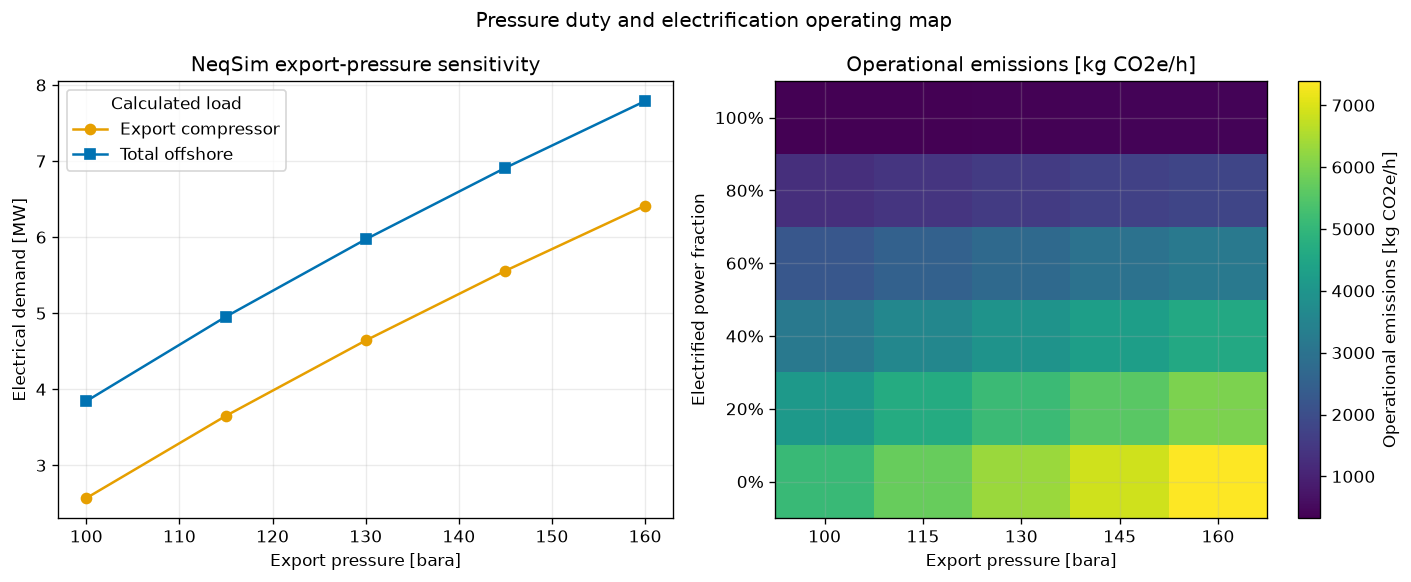

In [25]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.9),
)

axes[0].plot(
    pressure_table.index,
    pressure_table["Offshore compressor [MW]"],
    marker="o",
    color=ORANGE,
    label="Export compressor",
)
axes[0].plot(
    pressure_table.index,
    pressure_table["Offshore total [MW]"],
    marker="s",
    color=BLUE,
    label="Total offshore",
)
axes[0].set_xlabel("Export pressure [bara]")
axes[0].set_ylabel("Electrical demand [MW]")
axes[0].set_title("NeqSim export-pressure sensitivity")
axes[0].legend(title="Calculated load")

image = axes[1].imshow(
    sensitivity_matrix,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axes[1].set_xticks(
    range(len(export_pressures_bara)),
    [f"{pressure:.0f}" for pressure in export_pressures_bara],
)
axes[1].set_yticks(
    range(len(electrification_fractions)),
    [
        f"{fraction:.0%}"
        for fraction in electrification_fractions
    ],
)
axes[1].set_xlabel("Export pressure [bara]")
axes[1].set_ylabel("Electrified power fraction")
axes[1].set_title("Operational emissions [kg CO2e/h]")
colorbar = figure.colorbar(
    image,
    ax=axes[1],
)
colorbar.set_label("Operational emissions [kg CO2e/h]")

figure.suptitle(
    "Pressure duty and electrification operating map"
)
figure.tight_layout()
plt.show()

The map shows two independent levers. Raising export pressure increases
compression duty; increasing electrification reduces the supply factor. At high
electrification the removal vent becomes the visible lower bound.

## Cost of CO₂ removal and lower-carbon power

The original cost section is retained as a transparent screening calculation.
The alternatives include electrification, combined cycle, wind-backed power,
new technologies, and process intensification. Only the first three receive
synthetic costs here; the others require project-specific definition before a
numerical comparison is meaningful.

The annualized incremental cost is divided by avoided operational tonnes:

$$
C_{avoid} =
\frac{CAPEX \cdot CRF + OPEX}
{E_{base} - E_{option}}
$$

$C_{avoid}$ is USD/t CO₂e, $CRF$ is the capital-recovery factor, and annual
emissions use 8000 operating hours. Negative or zero avoidance is rejected.

In [26]:
cost_inputs = pd.DataFrame(
    {
        "Incremental CAPEX [million USD]": [
            130.0,
            180.0,
            260.0,
        ],
        "Incremental OPEX [million USD/year]": [
            4.0,
            3.0,
            6.0,
        ],
    },
    index=[
        "Combined cycle",
        "Power from shore",
        "Wind-backed hybrid",
    ],
)

discount_rate = 0.08
project_life_years = 20
capital_recovery_factor = (
    discount_rate
    * (1.0 + discount_rate) ** project_life_years
    / (
        (1.0 + discount_rate) ** project_life_years
        - 1.0
    )
)
baseline_annual_tonnes = (
    baseline_operational_kg_h
    * design_basis["Annual operating hours [h/year]"]
    / 1_000.0
)

avoided_cost_rows = []
for option_name, cost_row in cost_inputs.iterrows():
    option_annual_tonnes = (
        operational_emissions.loc[
            option_name,
            "Operational total [kg CO2e/h]",
        ]
        * design_basis["Annual operating hours [h/year]"]
        / 1_000.0
    )
    avoided_tonnes = (
        baseline_annual_tonnes - option_annual_tonnes
    )
    annualized_cost_usd = (
        cost_row["Incremental CAPEX [million USD]"]
        * 1.0e6
        * capital_recovery_factor
        + cost_row["Incremental OPEX [million USD/year]"]
        * 1.0e6
    )
    avoided_cost_rows.append(
        {
            "Option": option_name,
            "Avoided operational CO2e [t/year]": (
                avoided_tonnes
            ),
            "Annualized incremental cost [million USD/year]": (
                annualized_cost_usd / 1.0e6
            ),
            "Screening cost [USD/t CO2e]": (
                annualized_cost_usd / avoided_tonnes
            ),
        }
    )

avoided_cost_table = pd.DataFrame(
    avoided_cost_rows
).set_index("Option")
avoided_cost_table.round(2)

Out[26]: 
                    Avoided operational CO2e [t/year]  ...  Screening cost [USD/t CO2e]
Option                                                 ...                             
Combined cycle                               16068.03  ...                      1072.99
Power from shore                             50599.72  ...                       421.61
Wind-backed hybrid                           43469.15  ...                       747.23

[3 rows x 3 columns]


These costs rank the synthetic assumptions only. A project decision must include
power availability, grid connection, fuel opportunity cost, reliability,
redundancy, offshore weight and area, heat integration, CO₂ transport and
storage, construction emissions, tax, and uncertainty.

## Verification and acceptance checks

The checks test independent balances, physical directions, gas-quality bounds,
carbon allocation, scenario ordering, limiting cases, and finite outputs. Tight
mass tolerances verify solver connectivity; broader engineering bounds avoid
turning rounded display values into hidden benchmarks.

In [27]:
onshore_feed_kg_h = onshore_case["feed"].getFlowRate("kg/hr")
onshore_sales_kg_h = onshore_case["sales gas"].getFlowRate(
    "kg/hr"
)
onshore_liquid_kg_h = onshore_case["liquid"].getFlowRate(
    "kg/hr"
)
onshore_mass_residual = (
    onshore_feed_kg_h
    - onshore_sales_kg_h
    - onshore_liquid_kg_h
) / onshore_feed_kg_h

carbon_allocation_residual_kg_h = (
    raw_product_combustion_co2_kg_h
    - sales_gas_combustion_co2_kg_h
    - removed_co2_kg_h
)
removal_split_residual_kg_h = (
    removed_co2_kg_h
    - stored_co2_kg_h
    - removal_vent_co2_kg_h
)

checks = {
    "Input mole fractions sum to one": np.isclose(
        sum(feed_composition.values()),
        1.0,
        atol=1.0e-12,
    ),
    "NeqSim normalized composition sums to one": np.isclose(
        normalized_sum,
        1.0,
        atol=1.0e-12,
    ),
    "Offshore mass balance closes": (
        abs(normalized_mass_residual) < 1.0e-8
    ),
    "Onshore mass balance closes": (
        abs(onshore_mass_residual) < 1.0e-8
    ),
    "Export pressure is achieved": np.isclose(
        offshore_case["export gas"].getPressure("bara"),
        design_basis["Offshore export pressure [bara]"],
        atol=1.0e-6,
    ),
    "Transmission pressure is achieved": np.isclose(
        onshore_case["sales gas"].getPressure("bara"),
        design_basis["Transmission pressure [bara]"],
        atol=1.0e-6,
    ),
    "Both compressor powers are positive": (
        compressor_power_mw > 0.0
        and onshore_compressor_power_mw > 0.0
    ),
    "LCV is plausible for natural gas": (
        30_000.0 < fuel_lcv_kj_kg < 55_000.0
    ),
    "Fuel carbon factor is plausible": (
        2.0 < fuel_carbon_factor_kg_kg < 3.5
    ),
    "Combined cycle improves on simple cycle": (
        combined_cycle_factor < simple_cycle_factor
    ),
    "Shore power lowers operational emissions": (
        shore_operational_kg_h < baseline_operational_kg_h
    ),
    "Use-phase CO2 exceeds operational CO2e": (
        sales_gas_combustion_co2_kg_h
        > baseline_operational_kg_h
    ),
    "Removed CO2 split closes": (
        abs(removal_split_residual_kg_h) < 1.0e-8
    ),
    "Product carbon allocation closes": (
        abs(carbon_allocation_residual_kg_h) < 1.0e-8
    ),
    "Pressure cases close mass": (
        pressure_table[
            "Normalized mass residual [-]"
        ].abs().max()
        < 1.0e-8
    ),
    "Compressor power rises with export pressure": (
        np.diff(
            pressure_table["Offshore compressor [MW]"]
        )
        > 0.0
    ).all(),
    "Electrification lowers every pressure case": (
        sensitivity_matrix[-1, :]
        < sensitivity_matrix[0, :]
    ).all(),
    "All reported results are finite": np.isfinite(
        np.concatenate(
            [
                operational_emissions.to_numpy().ravel(),
                emissions_intensity.to_numpy().ravel(),
                sensitivity_matrix.ravel(),
                avoided_cost_table.to_numpy().ravel(),
            ]
        )
    ).all(),
    "All avoided-emission options are positive": (
        avoided_cost_table[
            "Avoided operational CO2e [t/year]"
        ]
        > 0.0
    ).all(),
}

for check_name, passed in checks.items():
    assert passed, check_name

pd.Series(checks, name="Passed").to_frame()

Out[27]: 
                                             Passed
Input mole fractions sum to one                True
NeqSim normalized composition sums to one      True
Offshore mass balance closes                   True
Onshore mass balance closes                    True
Export pressure is achieved                    True
Transmission pressure is achieved              True
Both compressor powers are positive            True
LCV is plausible for natural gas               True
Fuel carbon factor is plausible                True
Combined cycle improves on simple cycle        True
Shore power lowers operational emissions       True
Use-phase CO2 exceeds operational CO2e         True
Removed CO2 split closes                       True
Product carbon allocation closes               True
Pressure cases close mass                      True
Compressor power rises with export pressure    True
Electrification lowers every pressure case     True
All reported results are finite                True
Al

In [28]:
final_summary = pd.Series(
    {
        "Feed rate [kg/h]": feed_mass_kg_h,
        "Export gas [kg/h]": export_mass_kg_h,
        "Offshore power [MW]": offshore_total_power_mw,
        "Onshore power [MW]": onshore_total_power_mw,
        "Simple-cycle operational CO2e [kg/h]": (
            baseline_operational_kg_h
        ),
        "Shore-powered operational CO2e [kg/h]": (
            shore_operational_kg_h
        ),
        "Potential sales-gas use CO2 [kg/h]": (
            sales_gas_combustion_co2_kg_h
        ),
        "Captured CO2 [kg/h]": stored_co2_kg_h,
        "Baseline operational intensity [kg CO2e/boe]": (
            emissions_intensity.loc[
                "Simple-cycle gas turbine",
                "Operational [kg CO2e/boe]",
            ]
        ),
        "Engineering checks passed [-]": sum(checks.values()),
    },
    name="Validated base case",
)
final_summary.to_frame().round(4)

Out[28]: 
                                              Validated base case
Feed rate [kg/h]                                      173596.3237
Export gas [kg/h]                                     173596.3237
Offshore power [MW]                                        6.6060
Onshore power [MW]                                         4.6535
Simple-cycle operational CO2e [kg/h]                    6702.1332
Shore-powered operational CO2e [kg/h]                    377.1681
Potential sales-gas use CO2 [kg/h]                    468808.2997
Captured CO2 [kg/h]                                     3315.4316
Baseline operational intensity [kg CO2e/boe]               5.0348
Engineering checks passed [-]                             19.0000


## Troubleshooting

- **No JVM or import error:** run the setup cell once, then rerun from the imports
  cell. Do not mix a local JAR with the PyPI package.
- **Compressor failure:** confirm absolute pressures, positive gas flow, and a gas
  phase at the separator outlet. Start from a smaller pressure ratio.
- **Unexpected liquid:** inspect the aftercooler state and keep the scrubber
  liquid in the material balance.
- **Implausible heating value:** verify component names, composition sum, ISO
  edition, mass/volume basis, and reference temperatures.
- **Inventory mismatch:** keep kg/h, kW, kWh, kJ/kg, and annual hours explicit.
  Do not add captured CO₂ as a negative release.
- **Scope disagreement:** document organizational control and product-use
  assumptions before assigning Scope 1, 2, or 3.

## Summary

This notebook connects a real NeqSim process model to a deliberately separate
emissions-accounting layer. NeqSim calculates phase equilibrium, separator
products, compressor power, cooler duty, stream properties, and ISO 6976 gas
quality. The accounting layer derives fuel CO₂ from composition, compares power
supplies, separates operational and downstream boundaries, evaluates intensity,
and screens avoided-emissions cost.

The key engineering lesson is that facility electrification changes operational
emissions but not the carbon embodied in sales gas. Pressure optimization,
efficient generation, lower-carbon electricity, CO₂ capture, methane management,
and product substitution address different parts of the value chain.

## Further exercises

1. Replace the arrival valve with a NeqSim pipeline and find the minimum export
   pressure that satisfies delivery pressure.
2. Add two-stage offshore compression with intercooling and compare total power.
3. Replace the removal fractions with an amine or membrane model and close its
   mass and energy balances.
4. Add methane leakage and convert it to CO₂e with a clearly named assessment
   horizon and source.
5. Propagate uncertainty in flow, efficiency, electricity factor, capture rate,
   and annual hours with Monte Carlo sampling.
6. Expand the boundary to condensate, transport, construction, and end-use
   efficiency without double counting.

## Authoritative references

- [NeqSim process simulation documentation](https://equinor.github.io/neqsimhome/)
- [NeqSim compressor documentation](https://github.com/equinor/neqsim/blob/master/docs/process/equipment/compressors.md)
- [NeqSim ISO 6976 calorific-value documentation](https://github.com/equinor/neqsim/blob/master/docs/standards/iso6976_calorific_values.md)
- [ISO 6976:2016 — calculation of calorific values, density, relative density,
  and Wobbe indices](https://www.iso.org/standard/55842.html)
- [GHG Protocol Corporate Standard](https://ghgprotocol.org/corporate-standard)
- [GHG Protocol Scope 2 Guidance](https://ghgprotocol.org/scope-2-guidance)
- [GHG Protocol Scope 3 Calculation Guidance](https://ghgprotocol.org/scope-3-calculation-guidance-2)
- [IPCC 2006 Guidelines and 2019 Refinement](https://www.ipcc-nggip.iges.or.jp/public/2019rf/)

Always use the editions, factors, boundaries, and assurance requirements named
by the applicable contract, regulator, or reporting program.